In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pymannkendall as mk
import re
import numpy as np

In [2]:
# Figure Aesthetics
method_colors = {
    "method1": "#5B7FBF",  
    "method2": "#F77F00", 
    "method3": "#43AA8B",  
}

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

In [3]:
# Import data and organise
folder = Path("../disdata/raw_conaf_fire_event_data")

expected_columns = [
    'Región', 'Provincia', 'Comuna', 'Nombre incendio', 'Escenario',
    'Coord. operativas UTM E', 'Coord. operativas UTM N', 'Huso op.',
    'Coord. operativas Lat', 'Coord. operativas Lon', ' Inicio cercano a',
    ' Combustible inicial', 'Causa general',
    'Pino 0 a 10', 'Pino 11 a 17', 'Pino 18 o más', 'Eucalipto',
    'Otras plantaciones', 'Subtotal plantaciones', 'Arbolado', 'Matorral',
    'Pastizal', 'Subtotal vegetación natural', 'Agrícola', 'Desechos',
    'Subtotal otras superficies', 'Superficie total Has',
    'Inicio', 'Detección', 'Aviso', 'Despacho', 'Salida', 'Arribo',
    'Primer ataque', 'Control', 'Extinción', ' Duración (horas)',
    'Día de inicio', 'Temperatura °C', 'Humedad %', 'Exposición',
    'Dirección viento', 'Velocidad viento Km/hra', 'Topografía', 'Pendiente'
]

column_renames = {
    "Nombre incendo": "Nombre incendio",
    "Temperatura  °C": "Temperatura °C",
    "Superficie total": "Superficie total Has",
}

In [4]:
regions_of_interest = ["Biobío", "Araucanía", "Ñuble"]

month_map = {
    'ene': '01', 'feb': '02', 'mar': '03', 'abr': '04',
    'may': '05', 'jun': '06', 'jul': '07', 'ago': '08',
    'sep': '09', 'oct': '10', 'nov': '11', 'dic': '12'
}

def parse_spanish_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    date_str = str(date_str).lower()
    for es, num in month_map.items():
        if es in date_str:
            date_str = date_str.replace(es, num)
            break
    return pd.to_datetime(date_str, format="%d-%m-%Y %H:%M", errors="coerce")

In [5]:
csv_files = list(folder.glob("Base Datos*.csv"))
print(f"Found {len(csv_files)} files")
print(csv_files)

Found 24 files
[PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2018-2019.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2014-2015.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2016-2017.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2012-2013.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2008-2009.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2009-2010.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2011-2012.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2005-2006.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2019-2020.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2010-2011.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2025-2026.csv'), PosixPath('../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2007-2008.csv'), PosixPath('.

In [6]:
summary = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    row = {"file": csv_file.name, "n_rows": len(df)}
    for col in expected_columns:
        if col not in df.columns:
            row[col] = "MISSING"
        else:
            pct_empty = df[col].isna().mean() * 100
            row[col] = round(pct_empty, 1)
    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df.to_csv("../outputs/column_completeness_summary.csv", index=False)
summary_df

,file,n_rows,Región,Provincia,Comuna,Nombre incendio,Escenario,Coord. operativas UTM E,Coord. operativas UTM N,Huso op.,...,Extinción,Duración (horas),Día de inicio,Temperatura °C,Humedad %,Exposición,Dirección viento,Velocidad viento Km/hra,Topografía,Pendiente
0,Base Datos IIFF 2018-2019.csv,5325,0.0,0.0,0.0,0.0,3.6,0.0,0.0,0.0,...,0.0,0.0,0.0,1.4,1.4,3.8,1.4,1.4,3.8,0.0
1,Base Datos IIFF 2014-2015.csv,8073,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.8,7.0,40.5,8.1,8.6,43.9,37.5
2,Base Datos IIFF 2016-2017.csv,5274,0.0,0.0,0.0,0.0,31.0,0.1,0.1,0.1,...,0.6,0.6,0.0,2.3,2.4,31.4,3.5,3.6,31.0,0.0
3,Base Datos IIFF 2012-2013.csv,5651,0.0,0.0,0.0,0.0,100.0,1.2,1.2,1.2,...,1.4,1.4,0.0,10.2,10.5,47.4,35.5,31.2,46.6,41.8
4,Base Datos IIFF 2008-2009.csv,6157,0.0,0.0,0.0,0.0,99.7,4.0,4.0,4.0,...,0.0,0.0,0.0,71.0,71.2,98.7,99.9,71.8,68.5,90.2
5,Base Datos IIFF 2009-2010.csv,4069,0.0,0.0,0.0,0.0,99.8,0.0,0.0,0.0,...,0.0,0.0,0.0,47.9,54.5,99.3,99.8,55.2,46.5,96.0
6,Base Datos IIFF 2011-2012.csv,5509,0.0,0.0,0.0,0.0,100.0,10.6,10.6,10.6,...,0.0,0.0,0.0,53.1,53.2,97.2,98.2,70.4,49.2,89.3
7,Base Datos IIFF 2005-2006.csv,5396,0.0,0.0,0.0,0.0,100.0,4.1,4.1,4.1,...,2.0,2.0,0.0,62.1,62.4,98.7,97.6,64.6,57.5,95.6
8,Base Datos IIFF 2019-2020.csv,8127,0.0,0.0,0.0,0.0,34.1,0.0,0.0,0.0,...,0.0,0.0,0.0,22.8,22.8,35.8,22.9,23.0,35.8,0.0
9,Base Datos IIFF 2010-2011.csv,4951,0.0,0.0,0.0,0.0,94.3,0.2,0.2,0.2,...,0.0,0.0,0.0,22.5,22.4,91.9,93.0,25.5,52.6,82.0


## Non-Method / Raw Analysis

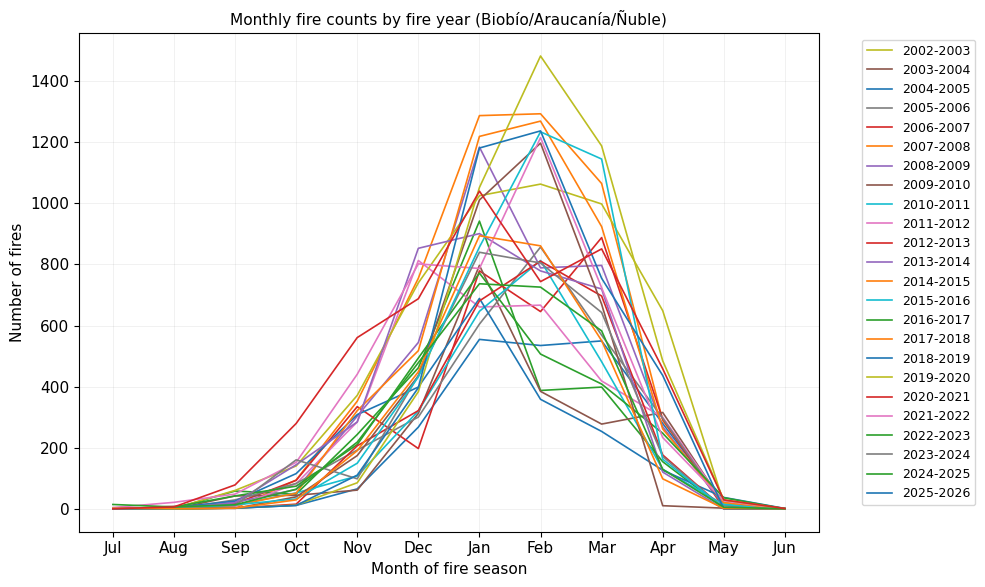

In [7]:
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 9,  # slightly smaller to fit many fire-year lines, still capped under 11
})
fig, ax = plt.subplots(figsize=(10, 6))
month_order = ["Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun"]
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])
    if len(df_filtered) == 0:
        continue
    # Month-of-season: July=0 ... June=11
    df_filtered["month_of_season"] = (df_filtered["Inicio"].dt.month - 7) % 12
    monthly_counts = df_filtered.groupby("month_of_season").size().reindex(range(12), fill_value=0)
    label = f"{year_start}-{year_start+1}"
    ax.plot(month_order, monthly_counts.values, label=label, linewidth=1.2)
ax.set_xlabel("Month of fire season")
ax.set_ylabel("Number of fires")
ax.set_title("Monthly fire counts by fire year (Biobío/Araucanía/Ñuble)")

# reorder legend entries chronologically by the year at the start of each label
handles, labels = ax.get_legend_handles_labels()
sorted_pairs = sorted(zip(labels, handles), key=lambda x: int(x[0].split("-")[0]))
labels, handles = zip(*sorted_pairs)
ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc="upper left", ncol=1)

ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.tight_layout()
plt.show()
fig.savefig("../outputs/monthly_fire_counts.png", dpi=400, bbox_inches="tight")

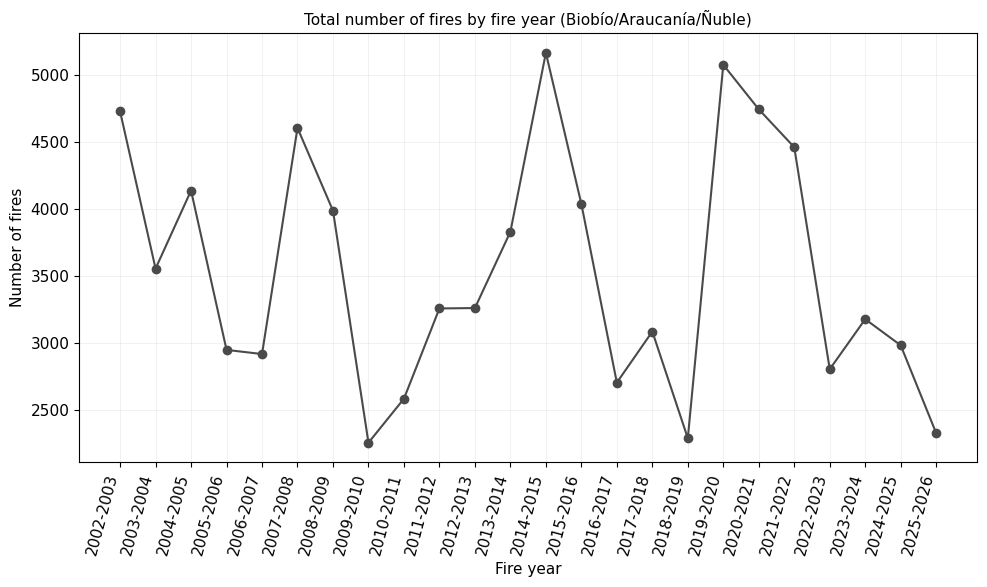

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

annual_counts = []
annual_labels = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])

    annual_counts.append(len(df_filtered))
    annual_labels.append(f"{year_start}-{year_start+1}")

# Sort by fire year start to ensure correct chronological order
sorted_pairs = sorted(zip(annual_labels, annual_counts), key=lambda x: int(x[0].split("-")[0]))
annual_labels, annual_counts = zip(*sorted_pairs)

ax.plot(annual_labels, annual_counts, marker="o", color="#4A4A4A", linewidth=1.5)
ax.set_xlabel("Fire year")
ax.set_ylabel("Number of fires")
ax.set_title("Total number of fires by fire year (Biobío/Araucanía/Ñuble)")
plt.xticks(rotation=75, ha="right")
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.tight_layout()
plt.show()

fig.savefig("../outputs/fig3_total_fires_by_year.png", dpi=400, bbox_inches="tight")

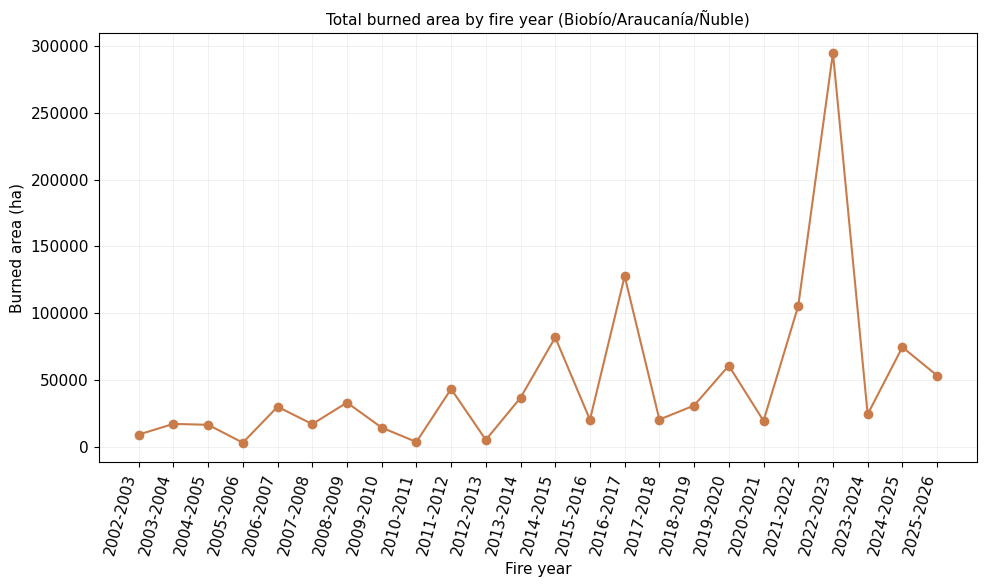

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

annual_burned_area = []
annual_labels = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])

    # Adjust column name to whatever your column_renames maps burned area to
    total_area = df_filtered["Superficie total Has"].sum()

    annual_burned_area.append(total_area)
    annual_labels.append(f"{year_start}-{year_start+1}")

# Sort by fire year start to ensure correct chronological order
sorted_pairs = sorted(zip(annual_labels, annual_burned_area), key=lambda x: int(x[0].split("-")[0]))
annual_labels, annual_burned_area = zip(*sorted_pairs)

ax.plot(annual_labels, annual_burned_area, marker="o", color="#C97B4A", linewidth=1.5)
ax.set_xlabel("Fire year")
ax.set_ylabel("Burned area (ha)")
ax.set_title("Total burned area by fire year (Biobío/Araucanía/Ñuble)")
plt.xticks(rotation=75, ha="right")
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.tight_layout()
plt.show()

fig.savefig("../outputs/fig3_burned_area_by_year.png", dpi=400, bbox_inches="tight")

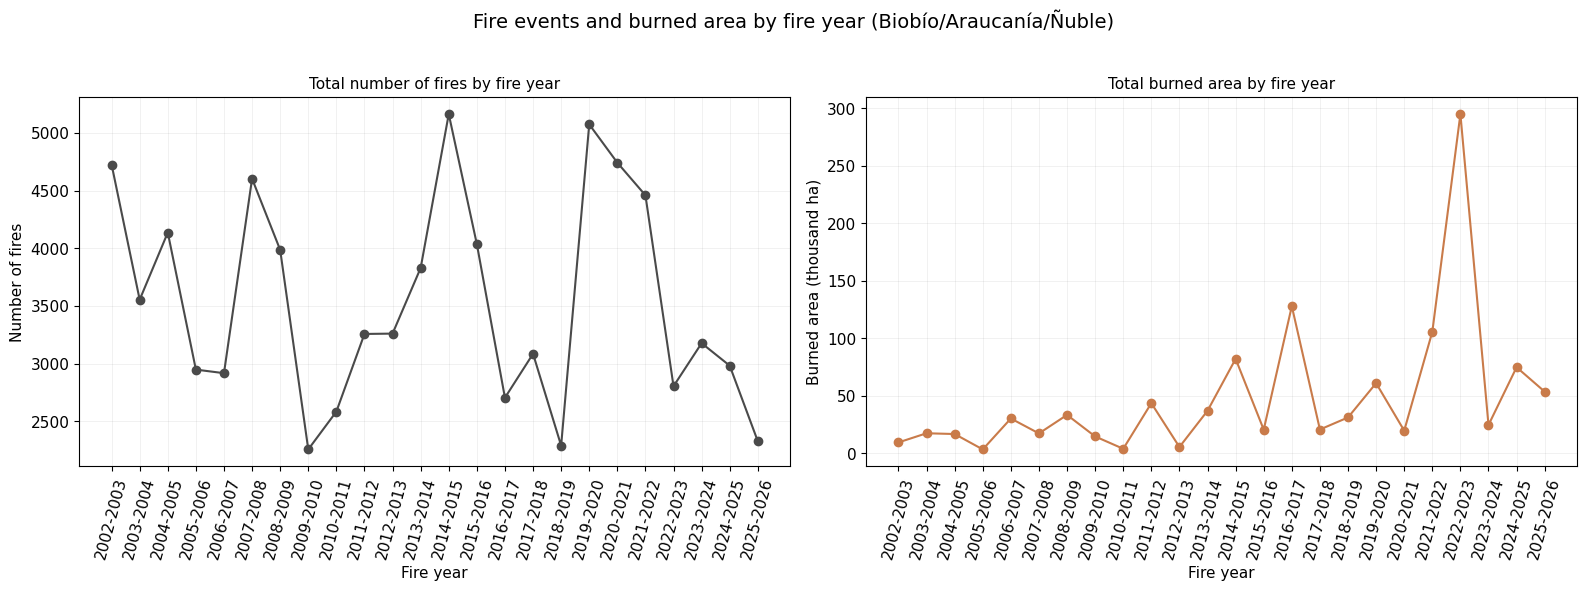

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# panel 1: number of fires
annual_counts = []
annual_labels = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])
    annual_counts.append(len(df_filtered))
    annual_labels.append(f"{year_start}-{year_start+1}")
sorted_pairs = sorted(zip(annual_labels, annual_counts), key=lambda x: int(x[0].split("-")[0]))
count_labels, count_values = zip(*sorted_pairs)

axes[0].plot(count_labels, count_values, marker="o", color="#4A4A4A", linewidth=1.5)
axes[0].set_xlabel("Fire year")
axes[0].set_ylabel("Number of fires")
axes[0].set_title("Total number of fires by fire year")
axes[0].tick_params(axis='x', rotation=75)
axes[0].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[0].set_axisbelow(True)

# panel 2: burned area
annual_burned_area = []
annual_labels = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])
    total_area = df_filtered["Superficie total Has"].sum()
    annual_burned_area.append(total_area)
    annual_labels.append(f"{year_start}-{year_start+1}")
sorted_pairs = sorted(zip(annual_labels, annual_burned_area), key=lambda x: int(x[0].split("-")[0]))
area_labels, area_values = zip(*sorted_pairs)

# convert to thousands of hectares to reduce zeros on the axis
area_values_thousands = [v / 1000 for v in area_values]

axes[1].plot(area_labels, area_values_thousands, marker="o", color="#C97B4A", linewidth=1.5)
axes[1].set_xlabel("Fire year")
axes[1].set_ylabel("Burned area (thousand ha)")
axes[1].set_title("Total burned area by fire year")
axes[1].tick_params(axis='x', rotation=75)
axes[1].grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
axes[1].set_axisbelow(True)

fig.suptitle("Fire events and burned area by fire year (Biobío/Araucanía/Ñuble)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle
plt.show()
fig.savefig("../outputs/fig3_fires_and_burned_area_panel.png", dpi=400, bbox_inches="tight")

In [11]:
import pymannkendall as mk

annual_summary = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])

    annual_summary.append({
        "fire_year": year_start,
        "n_fires": len(df_filtered),
        "burned_area_ha": df_filtered["Superficie total Has"].sum()
    })

annual_df = pd.DataFrame(annual_summary).sort_values("fire_year").reset_index(drop=True)

# Mann-Kendall trend test: burned area
mk_burned_area = mk.original_test(annual_df["burned_area_ha"])
print("Burned area trend:")
print(f"  Trend: {mk_burned_area.trend}")
print(f"  p-value: {mk_burned_area.p:.4f}")
print(f"  Sen's slope: {mk_burned_area.slope:.2f} ha/year")
print(f"  Tau: {mk_burned_area.Tau:.3f}")

print()

# Mann-Kendall trend test: number of fires
mk_n_fires = mk.original_test(annual_df["n_fires"])
print("Number of fires trend:")
print(f"  Trend: {mk_n_fires.trend}")
print(f"  p-value: {mk_n_fires.p:.4f}")
print(f"  Sen's slope: {mk_n_fires.slope:.2f} fires/year")
print(f"  Tau: {mk_n_fires.Tau:.3f}")

Burned area trend:
  Trend: increasing
  p-value: 0.0023
  Sen's slope: 2417.51 ha/year
  Tau: 0.449

Number of fires trend:
  Trend: no trend
  p-value: 0.4130
  Sen's slope: -27.95 fires/year
  Tau: -0.123


### For between 2002/3 to 2022/23

In [12]:
import pymannkendall as mk

annual_summary = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])
    annual_summary.append({
        "fire_year": year_start,
        "n_fires": len(df_filtered),
        "burned_area_ha": df_filtered["Superficie total Has"].sum()
    })

annual_df = pd.DataFrame(annual_summary).sort_values("fire_year").reset_index(drop=True)

# ending at fire year 2022/23
annual_df = annual_df[annual_df["fire_year"] <= 2022].reset_index(drop=True)

# Mann-Kendall trend test: burned area
mk_burned_area = mk.original_test(annual_df["burned_area_ha"])
print("Burned area trend:")
print(f"  Trend: {mk_burned_area.trend}")
print(f"  p-value: {mk_burned_area.p:.4f}")
print(f"  Sen's slope: {mk_burned_area.slope:.2f} ha/year")
print(f"  Tau: {mk_burned_area.Tau:.3f}")
print()

# Mann-Kendall trend test: number of fires
mk_n_fires = mk.original_test(annual_df["n_fires"])
print("Number of fires trend:")
print(f"  Trend: {mk_n_fires.trend}")
print(f"  p-value: {mk_n_fires.p:.4f}")
print(f"  Sen's slope: {mk_n_fires.slope:.2f} fires/year")
print(f"  Tau: {mk_n_fires.Tau:.3f}")

Burned area trend:
  Trend: increasing
  p-value: 0.0034
  Sen's slope: 3033.44 ha/year
  Tau: 0.467

Number of fires trend:
  Trend: no trend
  p-value: 0.9759
  Sen's slope: -7.77 fires/year
  Tau: -0.010


#### Comparing # Fire Events & Burned Area to different National Regions

In [13]:
import re

extended_to_34S = regions_of_interest + ["Maule", "O'Higgins"]  # extends to ~33.5-34°S

extended_to_28S = extended_to_34S + ["Metropolitana", "Valparaíso", "Coquimbo"]  # extends to ~28-29°S

region_groups = {
    "Study region (36-39°S)": regions_of_interest,
    "Extended to ~34°S": extended_to_34S,
    "Extended to ~28°S": extended_to_28S,
}

national_records = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df["Inicio"] = df["Inicio"].apply(parse_spanish_date)
    df["Superficie total Has"] = pd.to_numeric(df["Superficie total Has"], errors="coerce")

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df = df[
        (df["Inicio"] >= fire_year_start) &
        (df["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])

    df["fire_year"] = f"{year_start}-{year_start+1}"
    national_records.append(df)

national_df = pd.concat(national_records, ignore_index=True)

# National totals across entire time period
national_n_events = len(national_df)
national_burned_area = national_df["Superficie total Has"].sum()

print(f"National total events: {national_n_events}")
print(f"National total burned area: {national_burned_area:,.0f} ha")
print()

summary_rows = []
for label, regions in region_groups.items():
    subset = national_df[national_df["Región"].isin(regions)]
    n_events = len(subset)
    burned_area = subset["Superficie total Has"].sum()
    pct_events = (n_events / national_n_events) * 100
    pct_area = (burned_area / national_burned_area) * 100

    summary_rows.append({
        "domain": label,
        "n_events": n_events,
        "pct_of_national_events": round(pct_events, 2),
        "burned_area_ha": round(burned_area, 1),
        "pct_of_national_burned_area": round(pct_area, 2),
    })

summary_df_comparison = pd.DataFrame(summary_rows)
summary_df_comparison

National total events: 147247
National total burned area: 2,346,046 ha



,domain,n_events,pct_of_national_events,burned_area_ha,pct_of_national_burned_area
0,Study region (36-39°S),84898,57.66,1147149.7,48.9
1,Extended to ~34°S,106482,72.32,1848666.3,78.8
2,Extended to ~28°S,137650,93.48,2223934.9,94.8


In [14]:
mega_fire_years = ["2016-2017", "2022-2023"]  

national_df_excl = national_df[~national_df["fire_year"].isin(mega_fire_years)]
national_n_events_excl = len(national_df_excl)
national_burned_area_excl = national_df_excl["Superficie total Has"].sum()

summary_rows_excl = []
for label, regions in region_groups.items():
    subset = national_df_excl[national_df_excl["Región"].isin(regions)]
    n_events = len(subset)
    burned_area = subset["Superficie total Has"].sum()
    pct_events = (n_events / national_n_events_excl) * 100
    pct_area = (burned_area / national_burned_area_excl) * 100

    summary_rows_excl.append({
        "domain": label,
        "n_events": n_events,
        "pct_of_national_events": round(pct_events, 2),
        "burned_area_ha": round(burned_area, 1),
        "pct_of_national_burned_area": round(pct_area, 2),
    })

summary_df_excl = pd.DataFrame(summary_rows_excl)
print("Excluding 2016-17 and 2022-23 mega-fire seasons:")
summary_df_excl

Excluding 2016-17 and 2022-23 mega-fire seasons:


,domain,n_events,pct_of_national_events,burned_area_ha,pct_of_national_burned_area
0,Study region (36-39°S),79390,58.10,724672.7,50.91
1,Extended to ~34°S,98861,72.35,1040220.7,73.08
2,Extended to ~28°S,127716,93.46,1309165.5,91.98


#### Large Fire >200ha Statistics

In [15]:
annual_large_fires = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio"])

    df_filtered["Superficie total Has"] = pd.to_numeric(
        df_filtered["Superficie total Has"], errors="coerce"
    )

    n_large_fires = (df_filtered["Superficie total Has"] >= 200).sum()

    annual_large_fires.append({
        "fire_year": year_start,
        "n_fires_over_200ha": n_large_fires
    })

annual_large_df = pd.DataFrame(annual_large_fires).sort_values("fire_year").reset_index(drop=True)

# Mann-Kendall trend test: number of fires over 200 ha
mk_large_fires = mk.original_test(annual_large_df["n_fires_over_200ha"])
print("Number of fires over 200 ha, trend:")
print(f"  Trend: {mk_large_fires.trend}")
print(f"  p-value: {mk_large_fires.p:.4f}")
print(f"  Sen's slope: {mk_large_fires.slope:.3f} fires/year")
print(f"  Tau: {mk_large_fires.Tau:.3f}")

annual_large_df

Number of fires over 200 ha, trend:
  Trend: increasing
  p-value: 0.0024
  Sen's slope: 1.596 fires/year
  Tau: 0.446


,fire_year,n_fires_over_200ha
0,2002,4
1,2003,15
2,2004,11
3,2005,1
4,2006,23
5,2007,13
6,2008,33
7,2009,11
8,2010,0
9,2011,18


## Causes of Fires

In [16]:
# basic cause frequency 
cause_counts = df['Causa general'].value_counts()
cause_pct = df['Causa general'].value_counts(normalize=True) * 100

cause_summary = pd.DataFrame({
    'count': cause_counts,
    'percent': cause_pct.round(2)
})
print(cause_summary)

# main cause
main_cause = cause_counts.idxmax()
print(f"\nMain cause: {main_cause} ({cause_counts.max()} fires, {cause_pct.max():.1f}%)")

                                                    count  percent
Causa general                                                     
2.1 - Incendios intencionales                        2974    41.88
1.7 - Tránsito de personas  vehículos o aeronaves    1235    17.39
4.1 - Incendios de causa desconocida                  830    11.69
1.1 - Faenas forestales                               495     6.97
1.2 - Faenas agrícolas y pecuarias                    421     5.93
1.8 - Quema de desechos                               397     5.59
1.9 - Accidentes eléctricos                           218     3.07
1.4 - Actividades recreativas                         185     2.61
1.10 - Otras actividades                              114     1.61
1.6 - Actividades extinción incendios forestale...    100     1.41
1.3 - Confección y/o extracción productos secun...     59     0.83
3.1 - Incendios naturales                              56     0.79
1.5 - Operaciones en vías férreas                      17     

In [17]:
df['causa_clean'] = df['Causa general'].str.split(' - ').str[1]
print(df['causa_clean'].value_counts())

causa_clean
Incendios intencionales                                                         2974
Tránsito de personas  vehículos o aeronaves                                     1235
Incendios de causa desconocida                                                   830
Faenas forestales                                                                495
Faenas agrícolas y pecuarias                                                     421
Quema de desechos                                                                397
Accidentes eléctricos                                                            218
Actividades recreativas                                                          185
Otras actividades                                                                114
Actividades extinción incendios forestales   incendios estructurales u otros     100
Confección y/o extracción productos secundarios del bosque                        59
Incendios naturales                                  

In [18]:
area_by_cause = df.groupby('Causa general')['Superficie total Has'].agg(['sum', 'mean', 'count']).sort_values('sum', ascending=False)
area_by_cause.columns = ['total_ha', 'mean_ha_per_fire', 'n_fires']
print(area_by_cause)

                                                      total_ha  \
Causa general                                                    
2.1 - Incendios intencionales                       22141.0298   
4.1 - Incendios de causa desconocida                 2617.1656   
1.1 - Faenas forestales                              2311.1256   
1.2 - Faenas agrícolas y pecuarias                   2109.4030   
1.7 - Tránsito de personas  vehículos o aeronaves    1485.5840   
1.9 - Accidentes eléctricos                          1297.2831   
1.10 - Otras actividades                             1241.2700   
1.4 - Actividades recreativas                        1164.6400   
1.8 - Quema de desechos                               759.5438   
1.3 - Confección y/o extracción productos secun...    248.5830   
1.6 - Actividades extinción incendios forestale...    124.5672   
3.1 - Incendios naturales                             108.2890   
1.5 - Operaciones en vías férreas                      14.4000   

         

In [19]:
cause_by_region = pd.crosstab(df['Región'], df['Causa general'])
print(cause_by_region)

Causa general       1.1 - Faenas forestales  1.10 - Otras actividades  \
Región                                                                  
Antofagasta                               0                         0   
Araucanía                                92                         2   
Arica y Parinacota                        1                         0   
Atacama                                   1                         0   
Aysén                                     7                         0   
Biobío                                  145                        26   
Coquimbo                                  1                         0   
Los Lagos                                68                         0   
Los Ríos                                 31                         2   
Magallanes                                2                         9   
Maule                                    47                        14   
Metropolitana                            36        

In [20]:
# Cause by fire year by region
df_filtered['fire_year'] = df_filtered['Inicio'].apply(lambda d: d.year if d.month >= 7 else d.year - 1)

cause_by_year_region = pd.crosstab([df_filtered['fire_year'], df_filtered['Región']], df_filtered['Causa general'])
print(cause_by_year_region)

Causa general        1.1 - Faenas forestales  1.10 - Otras actividades  \
fire_year Región                                                         
2020      Araucanía                       92                         2   
          Biobío                         145                        26   
          Ñuble                           27                        18   

Causa general        1.2 - Faenas agrícolas y pecuarias  \
fire_year Región                                          
2020      Araucanía                                  70   
          Biobío                                     60   
          Ñuble                                      74   

Causa general        1.3 - Confección y/o extracción productos secundarios del bosque  \
fire_year Región                                                                        
2020      Araucanía                                                  1                  
          Biobío                                                  

## Inspecting Spikes from other data corroborating with this

In [21]:
# Top individual fires by burned area, fire year 2022/23
top_fires = df_filtered.sort_values("Superficie total Has", ascending=False).head(20)
print(top_fires[["Inicio", "Superficie total Has", "Región"]])

# Daily total burned area, sorted by largest days
daily_burned = df_filtered.groupby(df_filtered["Inicio"].dt.date)["Superficie total Has"].sum()
print("\nTop 15 days by total burned area:")
print(daily_burned.sort_values(ascending=False).head(15))

                  Inicio  Superficie total Has     Región
4950 2021-02-02 23:16:00               1405.00  Araucanía
3914 2021-01-18 16:51:00                680.00     Biobío
5949 2021-03-18 16:52:00                594.41  Araucanía
5593 2021-01-08 15:05:00                472.19  Araucanía
2976 2021-01-13 13:57:00                458.39     Biobío
5668 2021-01-23 15:11:00                442.19  Araucanía
5662 2021-01-22 11:05:00                311.43  Araucanía
5639 2021-01-18 17:04:00                294.69  Araucanía
5152 2021-01-20 15:44:00                288.80  Araucanía
3016 2021-01-21 11:00:00                288.30     Biobío
5732 2021-02-04 15:40:00                262.98  Araucanía
5714 2021-02-02 14:24:00                250.60  Araucanía
3149 2020-11-03 14:14:00                241.10      Ñuble
5652 2021-01-21 10:53:00                239.10  Araucanía
3609 2020-12-28 17:33:00                209.77      Ñuble
1674 2021-03-07 00:00:00                209.08     Biobío
5834 2021-02-2

In [22]:
spike_dates = ["2015-05-07", "2015-02-18"]

In [23]:
import re

target_year = 2014  # fire year 2014/15

# Find and load the CSV for this fire year
matching_file = None
for csv_file in csv_files:
    years_found = re.findall(r'\d{4}', csv_file.name)
    if int(years_found[0]) == target_year:
        matching_file = csv_file
        break

print("Using file:", matching_file)

df = pd.read_csv(matching_file, encoding="utf-8").rename(columns=column_renames)
df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

fire_year_start = pd.Timestamp(f"{target_year}-07-01")
fire_year_end = pd.Timestamp(f"{target_year+1}-06-30 23:59:59")
df_filtered = df_filtered[
    (df_filtered["Inicio"] >= fire_year_start) &
    (df_filtered["Inicio"] <= fire_year_end)
].dropna(subset=["Inicio"])

print(df_filtered["Inicio"].min(), df_filtered["Inicio"].max())

spike_dates_ts = pd.to_datetime(spike_dates).date
conaf_on_dates = df_filtered[df_filtered["Inicio"].dt.date.isin(spike_dates_ts)]
print(conaf_on_dates[["Inicio", "Superficie total Has", "Región"]].sort_values("Inicio"))

Using file: ../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2014-2015.csv
2014-08-18 12:30:00 2015-06-27 15:58:00
                  Inicio  Superficie total Has     Región
2575 2015-02-18 00:30:00                  5.10     Biobío
2073 2015-02-18 02:00:00                  2.50     Biobío
5065 2015-02-18 05:20:00                 78.00     Biobío
6217 2015-02-18 06:23:00                  1.50  Araucanía
5076 2015-02-18 07:45:00                  0.01     Biobío
...                  ...                   ...        ...
3772 2015-02-18 23:58:00                  1.20     Biobío
2190 2015-05-07 04:00:00                  0.20     Biobío
5496 2015-05-07 15:27:00                  0.02     Biobío
5498 2015-05-07 15:28:00                  1.25     Biobío
5497 2015-05-07 15:45:00                  4.50     Biobío

[61 rows x 3 columns]


In [24]:
# Were the fires on those dates the largest of the year
daily_burned = df_filtered.groupby(df_filtered["Inicio"].dt.date)["Superficie total Has"].sum()
daily_burned_sorted = daily_burned.sort_values(ascending=False)

print("Top 15 days by total burned area, fire year 2014/15:")
print(daily_burned_sorted.head(15))

print("\nRank of your spike dates:")
for d in spike_dates_ts:
    if d in daily_burned.index:
        rank = daily_burned_sorted.index.get_loc(d) + 1
        print(f"  {d}: {daily_burned.loc[d]:.2f} ha, rank {rank} of {len(daily_burned)} days")
    else:
        print(f"  {d}: no fires recorded")

Top 15 days by total burned area, fire year 2014/15:
Inicio
2015-02-26    9467.4245
2015-03-14    7309.8680
2015-03-25    6317.9210
2015-02-16    5210.9654
2015-02-17    4799.5439
2015-02-18    3804.4640
2015-02-25    3276.4064
2015-02-13    3099.9920
2015-03-10    3081.5525
2015-02-14    2871.8004
2015-03-11    2738.1301
2015-02-15    1974.2150
2015-01-11    1565.9018
2015-02-12    1521.2436
2015-02-07    1422.0092
Name: Superficie total Has, dtype: float64

Rank of your spike dates:
  2015-05-07: 5.97 ha, rank 148 of 224 days
  2015-02-18: 3804.46 ha, rank 6 of 224 days


In [25]:
spike_dates = ["2023-02-03", "2023-02-04", "2023-02-05"]

target_year = 2022  

# Find and load the CSV for this fire year
matching_file = None
for csv_file in csv_files:
    years_found = re.findall(r'\d{4}', csv_file.name)
    if int(years_found[0]) == target_year:
        matching_file = csv_file
        break

print("Using file:", matching_file)

df = pd.read_csv(matching_file, encoding="utf-8").rename(columns=column_renames)
df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)

fire_year_start = pd.Timestamp(f"{target_year}-07-01")
fire_year_end = pd.Timestamp(f"{target_year+1}-06-30 23:59:59")
df_filtered = df_filtered[
    (df_filtered["Inicio"] >= fire_year_start) &
    (df_filtered["Inicio"] <= fire_year_end)
].dropna(subset=["Inicio"])

print(df_filtered["Inicio"].min(), df_filtered["Inicio"].max())

spike_dates_ts = pd.to_datetime(spike_dates).date
conaf_on_dates = df_filtered[df_filtered["Inicio"].dt.date.isin(spike_dates_ts)]
print(conaf_on_dates[["Inicio", "Superficie total Has", "Región"]].sort_values("Inicio"))

Using file: ../disdata/raw_conaf_fire_event_data/Base Datos IIFF 2022-2023.csv
2022-08-01 16:48:00 2023-06-16 22:57:00
                  Inicio  Superficie total Has     Región
3904 2023-02-03 06:35:00                  0.06  Araucanía
3343 2023-02-03 07:56:00               6513.01  Araucanía
2407 2023-02-03 08:37:00                  7.16     Biobío
3344 2023-02-03 09:10:00                  2.00  Araucanía
2400 2023-02-03 10:01:00                  0.50     Biobío
...                  ...                   ...        ...
2415 2023-02-05 17:28:00                  7.00     Biobío
2417 2023-02-05 18:24:00                  2.00     Biobío
3392 2023-02-05 18:57:00                222.89  Araucanía
5151 2023-02-05 20:38:00                  1.00      Ñuble
3412 2023-02-05 20:39:00                  3.50  Araucanía

[100 rows x 3 columns]


In [26]:
# Were the fires on those dates the largest of the year
daily_burned = df_filtered.groupby(df_filtered["Inicio"].dt.date)["Superficie total Has"].sum()
daily_burned_sorted = daily_burned.sort_values(ascending=False)

print("Top 15 days by total burned area, fire year 2014/15:")
print(daily_burned_sorted.head(15))

print("\nRank of your spike dates:")
for d in spike_dates_ts:
    if d in daily_burned.index:
        rank = daily_burned_sorted.index.get_loc(d) + 1
        print(f"  {d}: {daily_burned.loc[d]:.2f} ha, rank {rank} of {len(daily_burned)} days")
    else:
        print(f"  {d}: no fires recorded")

Top 15 days by total burned area, fire year 2014/15:
Inicio
2023-02-03    105741.938
2023-02-02    105147.624
2023-02-04     13922.383
2023-02-01     11611.401
2023-02-17      8255.130
2022-12-29      7592.025
2023-01-28      6728.075
2023-02-07      3820.955
2023-02-06      3150.758
2023-02-11      1646.551
2023-02-22      1485.027
2023-01-16      1381.475
2023-02-05      1357.780
2023-02-08      1298.080
2022-12-30      1085.410
Name: Superficie total Has, dtype: float64

Rank of your spike dates:
  2023-02-03: 105741.94 ha, rank 1 of 239 days
  2023-02-04: 13922.38 ha, rank 3 of 239 days
  2023-02-05: 1357.78 ha, rank 13 of 239 days


## Method 1: Data Processing

In [27]:
results = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    n_before = len(df_filtered)
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ]
    n_excluded = n_before - len(df_filtered)

    first_date = df_filtered["Inicio"].min()
    last_ignition_date = df_filtered["Inicio"].max()
    last_date = df_filtered["Extinción"].max()

    season_length_days = (
        (last_date - first_date).days
        if pd.notna(first_date) and pd.notna(last_date)
        else None
    )

    results.append({
        "file": csv_file.name,
        "fire_year_start": fire_year_start,
        "first_ignition_date": first_date, # first ignition date
        "last_ignition_date": last_ignition_date,
        "last_extinction_date": last_date, # last extinction date
        "season_length_days": season_length_days,
        "n_excluded_outside_window": n_excluded
    })
results_df = pd.DataFrame(results)
results_df

,file,fire_year_start,first_ignition_date,last_ignition_date,last_extinction_date,season_length_days,n_excluded_outside_window
0,Base Datos IIFF 2018-2019.csv,2018-07-01,2018-07-16 11:50:00,2019-06-20 17:38:00,2019-11-26 17:35:00,498,0
1,Base Datos IIFF 2014-2015.csv,2014-07-01,2014-08-18 12:30:00,2015-06-27 15:58:00,2015-10-26 20:25:00,434,0
2,Base Datos IIFF 2016-2017.csv,2016-07-01,2016-08-28 14:21:00,2017-06-12 16:16:00,2017-08-29 13:00:00,365,0
3,Base Datos IIFF 2012-2013.csv,2012-07-01,2012-07-06 13:40:00,2013-05-15 10:02:00,2013-05-17 01:30:00,314,0
4,Base Datos IIFF 2008-2009.csv,2008-07-01,2008-09-13 17:05:00,2009-05-07 15:38:00,2009-05-07 19:30:00,236,0
5,Base Datos IIFF 2009-2010.csv,2009-07-01,2009-09-20 18:30:00,2010-06-10 14:05:00,2010-06-11 08:34:00,263,0
6,Base Datos IIFF 2011-2012.csv,2011-07-01,2011-09-25 15:34:00,2012-05-23 15:21:00,2012-05-23 17:54:00,241,0
7,Base Datos IIFF 2005-2006.csv,2005-07-01,2005-07-25 17:40:00,2006-05-15 12:36:00,2006-06-03 23:00:00,313,0
8,Base Datos IIFF 2019-2020.csv,2019-07-01,2019-07-05 12:05:00,2020-06-18 14:34:00,2020-06-18 15:10:00,349,0
9,Base Datos IIFF 2010-2011.csv,2010-07-01,2010-08-04 09:00:00,2011-05-31 20:23:00,2011-05-31 23:59:00,300,0


In [28]:
# Find the fire(s) driving the last_extinction_date each year to see if there are any issues with the data or not
for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)
    if df_filtered["Extinción"].notna().any():
        idx_max = df_filtered["Extinción"].idxmax()
        print(csv_file.name, "-> longest-burning fire extinguished:",
              df_filtered.loc[idx_max, "Extinción"],
              "ignited:", df_filtered.loc[idx_max, "Inicio"])

Base Datos IIFF 2018-2019.csv -> longest-burning fire extinguished: 2019-11-26 17:35:00 ignited: 2019-04-12 13:35:00
Base Datos IIFF 2014-2015.csv -> longest-burning fire extinguished: 2015-10-26 20:25:00 ignited: 2014-10-26 20:10:00
Base Datos IIFF 2016-2017.csv -> longest-burning fire extinguished: 2017-08-29 13:00:00 ignited: 2017-01-31 14:14:00
Base Datos IIFF 2012-2013.csv -> longest-burning fire extinguished: 2013-05-17 01:30:00 ignited: 2013-04-16 21:18:00
Base Datos IIFF 2008-2009.csv -> longest-burning fire extinguished: 2009-05-07 19:30:00 ignited: 2009-05-07 15:38:00
Base Datos IIFF 2009-2010.csv -> longest-burning fire extinguished: 2010-06-11 08:34:00 ignited: 2010-06-10 14:05:00
Base Datos IIFF 2011-2012.csv -> longest-burning fire extinguished: 2012-05-23 17:54:00 ignited: 2012-05-23 15:21:00
Base Datos IIFF 2005-2006.csv -> longest-burning fire extinguished: 2006-06-03 23:00:00 ignited: 2006-01-29 01:43:00
Base Datos IIFF 2019-2020.csv -> longest-burning fire extinguish

In [29]:
target_files = [
    "Base Datos IIFF 2013-2014.csv",
    "Base Datos IIFF 2021-2022.csv",
    "Base Datos IIFF 2007-2008.csv",
]

for csv_file in csv_files:
    if csv_file.name not in target_files:
        continue

    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)

    df_filtered["calculated_duration_hours"] = (
        df_filtered["Extinción"] - df_filtered["Inicio"]
    ).dt.total_seconds() / 3600
    df_filtered["reported_duration_hours"] = pd.to_numeric(
        df_filtered[" Duración (horas)"], errors="coerce"
    )
    df_filtered["duration_diff_hours"] = (
        df_filtered["calculated_duration_hours"] - df_filtered["reported_duration_hours"]
    )

    top_mismatch = df_filtered.sort_values("duration_diff_hours", ascending=False).head(3)
    print(csv_file.name)
    print(top_mismatch[["Inicio", "Extinción", "calculated_duration_hours", "reported_duration_hours", "duration_diff_hours"]])
    print()

Base Datos IIFF 2007-2008.csv
                  Inicio           Extinción  calculated_duration_hours  \
1636 2008-01-23 21:50:00 2008-03-19 16:28:00                1338.633333   
1698 2008-02-07 18:30:00 2008-03-19 17:20:00                 982.833333   
4980 2008-01-27 22:00:00 2008-02-25 12:50:00                 686.833333   

      reported_duration_hours  duration_diff_hours  
1636                   1338.6             0.033333  
1698                    982.8             0.033333  
4980                    686.8             0.033333  

Base Datos IIFF 2013-2014.csv
                  Inicio           Extinción  calculated_duration_hours  \
1799 2013-08-23 22:15:00 2013-11-15 23:59:00                2017.733333   
2448 2013-10-10 21:00:00 2014-03-08 13:45:00                3568.750000   
2445 2013-10-07 17:34:00 2014-01-15 18:13:00                2400.650000   

      reported_duration_hours  duration_diff_hours  
1799                   2016.7             1.033333  
2448               

In [30]:
target_files = [
    "Base Datos IIFF 2013-2014.csv",
    "Base Datos IIFF 2021-2022.csv",
    "Base Datos IIFF 2007-2008.csv",
]

for csv_file in csv_files:
    if csv_file.name not in target_files:
        continue

    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)

    df_filtered["calculated_duration_hours"] = (
        df_filtered["Extinción"] - df_filtered["Inicio"]
    ).dt.total_seconds() / 3600
    df_filtered["reported_duration_hours"] = pd.to_numeric(
        df_filtered[" Duración (horas)"], errors="coerce"
    )
    df_filtered["duration_diff_hours"] = (
        df_filtered["calculated_duration_hours"] - df_filtered["reported_duration_hours"]
    )

    # Find the row with the single longest calculated duration (the previously flagged outlier)
    idx_max = df_filtered["calculated_duration_hours"].idxmax()
    row = df_filtered.loc[idx_max]
    print(csv_file.name)
    print(f"  Inicio: {row['Inicio']}")
    print(f"  Extinción: {row['Extinción']}")
    print(f"  calculated_duration_hours: {row['calculated_duration_hours']:.1f}")
    print(f"  reported_duration_hours: {row['reported_duration_hours']}")
    print(f"  duration_diff_hours: {row['duration_diff_hours']:.1f}")
    print()

Base Datos IIFF 2007-2008.csv
  Inicio: 2007-11-12 18:05:00
  Extinción: 2008-03-01 12:00:00
  calculated_duration_hours: 2633.9
  reported_duration_hours: 2633.9
  duration_diff_hours: 0.0

Base Datos IIFF 2013-2014.csv
  Inicio: 2014-01-06 16:46:00
  Extinción: 2015-01-07 10:45:00
  calculated_duration_hours: 8778.0
  reported_duration_hours: 8778.0
  duration_diff_hours: -0.0

Base Datos IIFF 2021-2022.csv
  Inicio: 2021-12-23 09:03:00
  Extinción: 2022-12-23 16:28:00
  calculated_duration_hours: 8767.4
  reported_duration_hours: 8767.4
  duration_diff_hours: 0.0



In [31]:
duration_summary = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()

    df_filtered["reported_duration_hours"] = pd.to_numeric(
        df_filtered[" Duración (horas)"], errors="coerce"
    )

    duration_summary.append(df_filtered[["reported_duration_hours"]])

all_durations = pd.concat(duration_summary, ignore_index=True)
all_durations = all_durations.dropna(subset=["reported_duration_hours"])

# Thresholds in hours
three_months_hours = 3 * 30 * 24   # approx 2160 hours
six_months_hours = 6 * 30 * 24     # approx 4320 hours

n_total = len(all_durations)
n_over_3_months = (all_durations["reported_duration_hours"] > three_months_hours).sum()
n_over_6_months = (all_durations["reported_duration_hours"] > six_months_hours).sum()

pct_over_3_months = (n_over_3_months / n_total) * 100
pct_over_6_months = (n_over_6_months / n_total) * 100

print(f"Total fires with valid duration data: {n_total}")
print(f"Fires with duration > 3 months: {n_over_3_months} ({pct_over_3_months:.3f}%)")
print(f"Fires with duration > 6 months: {n_over_6_months} ({pct_over_6_months:.3f}%)")

Total fires with valid duration data: 84741
Fires with duration > 3 months: 245 (0.289%)
Fires with duration > 6 months: 15 (0.018%)


In [32]:
# Find the fire(s) with negative duration
negative_duration_rows = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)
    df_filtered["reported_duration_hours"] = pd.to_numeric(
        df_filtered[" Duración (horas)"], errors="coerce"
    )

    negatives = df_filtered[df_filtered["reported_duration_hours"] < 0][
        ["Inicio", "Extinción", "reported_duration_hours"]
    ].copy()
    if len(negatives) > 0:
        negatives["file"] = csv_file.name
        negative_duration_rows.append(negatives)

if negative_duration_rows:
    negative_duration_df = pd.concat(negative_duration_rows, ignore_index=True)
    print(negative_duration_df)
else:
    print("No negative durations found")

               Inicio           Extinción  reported_duration_hours  \
0 2019-01-27 14:10:00 2019-01-27 13:30:00                     -0.7   
1 2019-04-05 22:38:00 2019-01-06 00:01:00                  -2158.6   
2 2015-02-25 20:00:00 2015-02-21 20:00:00                    -96.0   
3 2017-02-27 00:00:00 2017-02-22 00:00:00                   -120.0   
4 2017-01-26 15:00:00 2017-01-26 00:00:00                    -15.0   
5 2013-03-20 18:58:00 2013-03-19 19:25:00                    -23.6   
6 2013-03-13 00:00:00 2013-02-16 00:36:00                   -599.4   
7 2013-03-18 20:50:00 2013-02-26 23:19:00                   -477.5   
8 2015-10-11 14:02:00 1969-12-31 20:00:00                -401274.0   

                            file  
0  Base Datos IIFF 2018-2019.csv  
1  Base Datos IIFF 2018-2019.csv  
2  Base Datos IIFF 2014-2015.csv  
3  Base Datos IIFF 2016-2017.csv  
4  Base Datos IIFF 2016-2017.csv  
5  Base Datos IIFF 2012-2013.csv  
6  Base Datos IIFF 2012-2013.csv  
7  Base Datos IIFF 

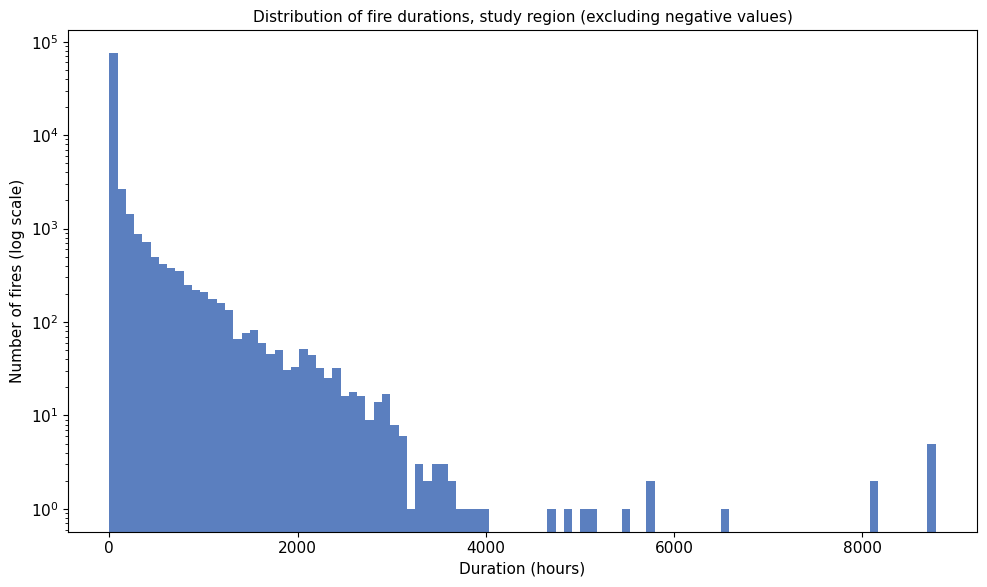

95th percentile: 357.0 hours (14.9 days)
99th percentile: 1260.4 hours (52.5 days)
99.5th percentile: 1772.8 hours (73.9 days)
99.9th percentile: 2732.8 hours (113.9 days)


In [33]:
# build a histogram excluding negative/implausible durations for a readable view
valid_durations = all_durations[all_durations["reported_duration_hours"] >= 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(valid_durations["reported_duration_hours"], bins=100, color="#5B7FBF")
ax.set_yscale("log")
ax.set_xlabel("Duration (hours)")
ax.set_ylabel("Number of fires (log scale)")
ax.set_title("Distribution of fire durations, study region (excluding negative values)")
plt.tight_layout()
plt.show()

for p in [95, 99, 99.5, 99.9]:
    val_hours = np.percentile(valid_durations["reported_duration_hours"], p)
    print(f"{p}th percentile: {val_hours:.1f} hours ({val_hours/24:.1f} days)")

In [34]:
# Confirm the gap: count fires in narrow bins between 2500 and 8500 hours
gap_check = valid_durations[
    (valid_durations["reported_duration_hours"] > 2500) &
    (valid_durations["reported_duration_hours"] < 8500)
].sort_values("reported_duration_hours")
gap_check

,reported_duration_hours
76234,2527.5
65971,2530.3
42649,2531.9
65970,2531.9
2191,2532.5
...,...
76658,5754.0
76657,5758.9
76511,6498.8
76246,8105.9


In [35]:
# Method 1: ignition-to-extinction, with implausible duration exclusions 

DURATION_CUTOFF_HOURS = 2732.8  # 99.9th percentile of fire duration distribution

combined_records = []
excluded_fires_log = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    df_filtered["Extinción"] = df_filtered["Extinción"].apply(parse_spanish_date)
    df_filtered["reported_duration_hours"] = pd.to_numeric(
        df_filtered[" Duración (horas)"], errors="coerce"
    )

    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")

    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ]

    # Calculated duration from date columns
    df_filtered["calculated_duration_hours"] = (
        df_filtered["Extinción"] - df_filtered["Inicio"]
    ).dt.total_seconds() / 3600

    # Flag implausible durations: negative, or beyond the cutoff
    implausible_mask = (
        (df_filtered["calculated_duration_hours"] < 0) |
        (df_filtered["calculated_duration_hours"] > DURATION_CUTOFF_HOURS)
    )

    if implausible_mask.sum() > 0:
        flagged = df_filtered.loc[implausible_mask, ["Inicio", "Extinción", "calculated_duration_hours"]].copy()
        flagged["file"] = csv_file.name
        excluded_fires_log.append(flagged)

    df_filtered = df_filtered.loc[~implausible_mask].copy()

    df_filtered["fire_year"] = f"{year_start}-{year_start+1}"
    df_filtered["source_file"] = csv_file.name
    combined_records.append(df_filtered)

combined_df = pd.concat(combined_records, ignore_index=True)
print(f"Combined shape: {combined_df.shape}")
print(f"Fire years included: {sorted(combined_df['fire_year'].unique())}")

output_path = Path("../outputs/combined_conaf_fire_records.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
combined_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

# Log of every fire excluded for implausible duration
if excluded_fires_log:
    excluded_fires_df = pd.concat(excluded_fires_log, ignore_index=True)
    excluded_log_path = Path("../outputs/excluded_implausible_duration_fires.csv")
    excluded_fires_df.to_csv(excluded_log_path, index=False)
    print(f"Excluded {len(excluded_fires_df)} implausible-duration fires, logged to {excluded_log_path}")
else:
    print("No implausible fires excluded")

Combined shape: (84804, 61)
Fire years included: ['2002-2003', '2003-2004', '2004-2005', '2005-2006', '2006-2007', '2007-2008', '2008-2009', '2009-2010', '2010-2011', '2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021', '2021-2022', '2022-2023', '2023-2024', '2024-2025', '2025-2026']
Saved to ../outputs/combined_conaf_fire_records.csv
Excluded 94 implausible-duration fires, logged to ../outputs/excluded_implausible_duration_fires.csv


## Method 1: Calculation & Figures FSL in Study Region 

In [36]:
# calculate Method 1 season lengths from the already-cleaned combined_df
method1_summary = (
    combined_df.groupby("fire_year")
    .agg(
        first_ignition_date=("Inicio", "min"),
        last_ignition_date=("Inicio", "max"),
        last_extinction_date=("Extinción", "max"),
    )
    .reset_index()
)

method1_summary["season_length_days"] = (
    method1_summary["last_extinction_date"] - method1_summary["first_ignition_date"]
).dt.days

# Sort chronologically by the start year of each fire_year label
method1_summary = method1_summary.sort_values(
    "fire_year", key=lambda s: s.str.split("-").str[0].astype(int)
).reset_index(drop=True)

method1_summary

,fire_year,first_ignition_date,last_ignition_date,last_extinction_date,season_length_days
0,2002-2003,2002-07-15 10:15:00,2003-06-06 16:33:00,2003-06-06 18:09:00,326
1,2003-2004,2003-08-24 22:00:00,2004-05-20 10:00:00,2004-05-31 20:00:00,280
2,2004-2005,2004-08-17 18:00:00,2005-05-24 11:32:00,2005-05-24 12:21:00,279
3,2005-2006,2005-07-25 17:40:00,2006-05-15 12:36:00,2006-05-15 21:00:00,294
4,2006-2007,2006-09-17 16:31:00,2007-06-04 18:00:00,2007-06-05 07:00:00,260
5,2007-2008,2007-08-02 17:00:00,2008-05-16 20:47:00,2008-05-16 21:33:00,288
6,2008-2009,2008-09-13 17:05:00,2009-05-07 15:38:00,2009-05-07 19:30:00,236
7,2009-2010,2009-09-20 18:30:00,2010-06-10 14:05:00,2010-06-11 08:34:00,263
8,2010-2011,2010-08-04 09:00:00,2011-05-31 20:23:00,2011-05-31 23:59:00,300
9,2011-2012,2011-09-25 15:34:00,2012-05-23 15:21:00,2012-05-23 17:54:00,241


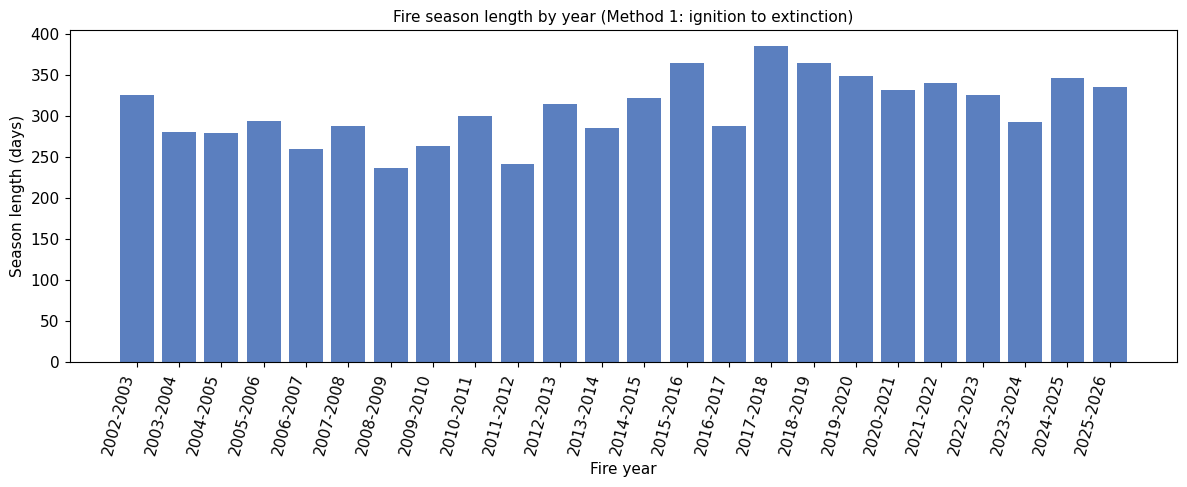

In [37]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(method1_summary["fire_year"], method1_summary["season_length_days"],
       color=method_colors["method1"])
ax.set_xlabel("Fire year")
ax.set_ylabel("Season length (days)")
ax.set_title("Fire season length by year (Method 1: ignition to extinction)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fig_m1_fsl_length.png", dpi=400, bbox_inches="tight")

## Method 1: FSL Duration Timeseries in Study Region

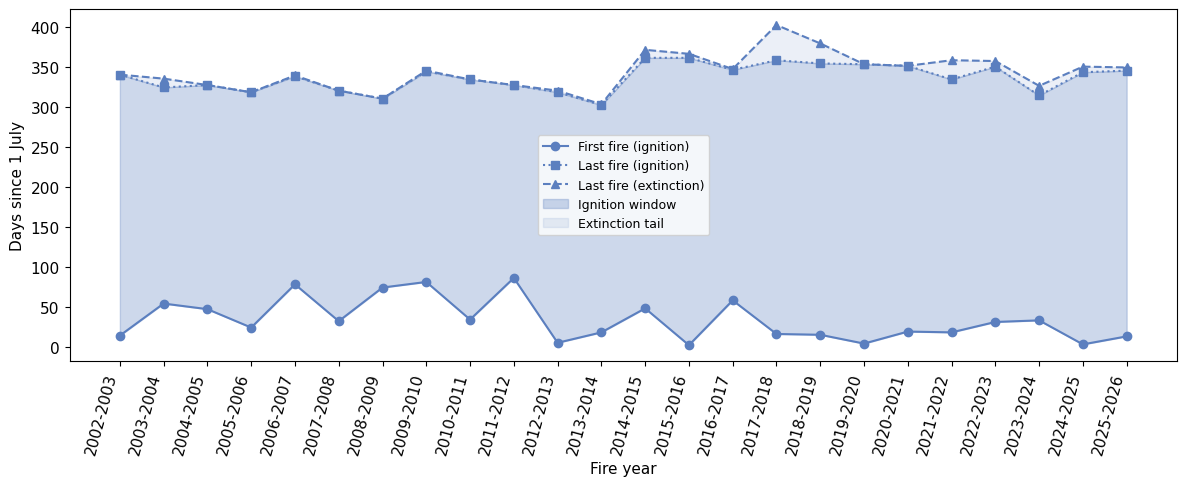

In [38]:
# first_day, last_ignition_day, and last_day relative to fire_year_start
method1_summary["fire_year_start"] = pd.to_datetime(
    method1_summary["fire_year"].str.split("-").str[0] + "-07-01"
)
method1_summary["first_day"] = (method1_summary["first_ignition_date"] - method1_summary["fire_year_start"]).dt.days
method1_summary["last_ignition_day"] = (method1_summary["last_ignition_date"] - method1_summary["fire_year_start"]).dt.days
method1_summary["last_day"] = (method1_summary["last_extinction_date"] - method1_summary["fire_year_start"]).dt.days

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(method1_summary["fire_year"], method1_summary["first_day"], marker="o", linestyle="-",
        color=method_colors["method1"], label="First fire (ignition)")
ax.plot(method1_summary["fire_year"], method1_summary["last_ignition_day"], marker="s", linestyle=":",
        color=method_colors["method1"], label="Last fire (ignition)")
ax.plot(method1_summary["fire_year"], method1_summary["last_day"], marker="^", linestyle="--",
        color=method_colors["method1"], label="Last fire (extinction)")

# Shade ignition-only window (first to last ignition) darker
ax.fill_between(method1_summary["fire_year"], method1_summary["first_day"], method1_summary["last_ignition_day"],
                 color=method_colors["method1"], alpha=0.3, label="Ignition window")
# Shade extinction tail (last ignition to last extinction) lighter
ax.fill_between(method1_summary["fire_year"], method1_summary["last_ignition_day"], method1_summary["last_day"],
                 color=method_colors["method1"], alpha=0.12, label="Extinction tail")

ax.set_xlabel("Fire year")
ax.set_ylabel("Days since 1 July")
ax.legend()
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fig_m1_fsl_duration.png", dpi=400, bbox_inches="tight")

In [39]:
# Drop any years with missing season length before testing
trend_data = method1_summary.dropna(subset=["season_length_days"]).copy()
trend_data = trend_data.sort_values("fire_year_start").reset_index(drop=True)
mk_result = mk.original_test(trend_data["season_length_days"])
print(f"Trend: {mk_result.trend}")
print(f"p-value: {mk_result.p:.4f}")
print(f"Sen's slope: {mk_result.slope:.3f} days/year")
print(f"Tau: {mk_result.Tau:.3f}")
print(f"Significant at 0.05: {mk_result.h}")

Trend: increasing
p-value: 0.0085
Sen's slope: 3.000 days/year
Tau: 0.388
Significant at 0.05: True


## Method 2

In [40]:
# Build cumulative burned area per file, find 5th-95th percentile dates
method2_results = []

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ]
    
    # Drop rows with missing area or missing date
    df_filtered = df_filtered.dropna(subset=["Inicio", "Superficie total Has"])
    df_filtered = df_filtered.sort_values("Inicio")
    
    if len(df_filtered) == 0:
        method2_results.append({
            "file": csv_file.name, "fire_year_start": fire_year_start,
            "p5_date": None, "p95_date": None, "season_length_days": None
        })
        continue
    
    df_filtered["cumulative_area"] = df_filtered["Superficie total Has"].cumsum()
    total_area = df_filtered["cumulative_area"].iloc[-1]
    
    p5_threshold = 0.05 * total_area
    p95_threshold = 0.95 * total_area
    
    p5_date = df_filtered.loc[df_filtered["cumulative_area"] >= p5_threshold, "Inicio"].iloc[0]
    p95_date = df_filtered.loc[df_filtered["cumulative_area"] >= p95_threshold, "Inicio"].iloc[0]
    
    season_length_days = (p95_date - p5_date).days
    
    method2_results.append({
        "file": csv_file.name,
        "fire_year_start": fire_year_start,
        "total_area_ha": total_area,
        "p5_date": p5_date,
        "p95_date": p95_date,
        "season_length_days": season_length_days
    })

method2_df = pd.DataFrame(method2_results)
method2_df

,file,fire_year_start,total_area_ha,p5_date,p95_date,season_length_days
0,Base Datos IIFF 2018-2019.csv,2018-07-01,31093.2260,2019-01-18 09:43:00,2019-04-03 15:56:00,75
1,Base Datos IIFF 2014-2015.csv,2014-07-01,81999.1191,2015-01-10 11:18:00,2015-03-25 04:40:00,73
2,Base Datos IIFF 2016-2017.csv,2016-07-01,127770.2618,2017-01-20 22:33:00,2017-01-28 10:00:00,7
3,Base Datos IIFF 2012-2013.csv,2012-07-01,5415.8659,2012-09-06 01:00:00,2013-04-18 17:50:00,224
4,Base Datos IIFF 2008-2009.csv,2008-07-01,33302.2200,2009-01-03 04:00:00,2009-04-08 14:43:00,95
5,Base Datos IIFF 2009-2010.csv,2009-07-01,14590.1500,2010-01-10 17:01:00,2010-04-04 21:55:00,84
6,Base Datos IIFF 2011-2012.csv,2011-07-01,43491.4100,2011-12-25 15:50:00,2012-02-13 18:21:00,50
7,Base Datos IIFF 2005-2006.csv,2005-07-01,3312.7600,2005-11-03 14:00:00,2006-04-10 09:04:00,157
8,Base Datos IIFF 2019-2020.csv,2019-07-01,60898.8498,2020-01-01 18:36:00,2020-04-03 15:53:00,92
9,Base Datos IIFF 2010-2011.csv,2010-07-01,3855.8400,2010-12-06 13:08:00,2011-03-27 18:30:00,111


In [41]:
# Stats for Method 2
trend_data_m2 = method2_df.dropna(subset=["season_length_days"]).copy()
trend_data_m2 = trend_data_m2.sort_values("fire_year_start").reset_index(drop=True)

mk_result_m2 = mk.original_test(trend_data_m2["season_length_days"])

print(f"Trend: {mk_result_m2.trend}")
print(f"p-value: {mk_result_m2.p:.4f}")
print(f"Sen's slope: {mk_result_m2.slope:.3f} days/year")
print(f"Tau: {mk_result_m2.Tau:.3f}")
print(f"Significant at 0.05: {mk_result_m2.h}")

Trend: no trend
p-value: 0.2971
Sen's slope: -1.000 days/year
Tau: -0.156
Significant at 0.05: False


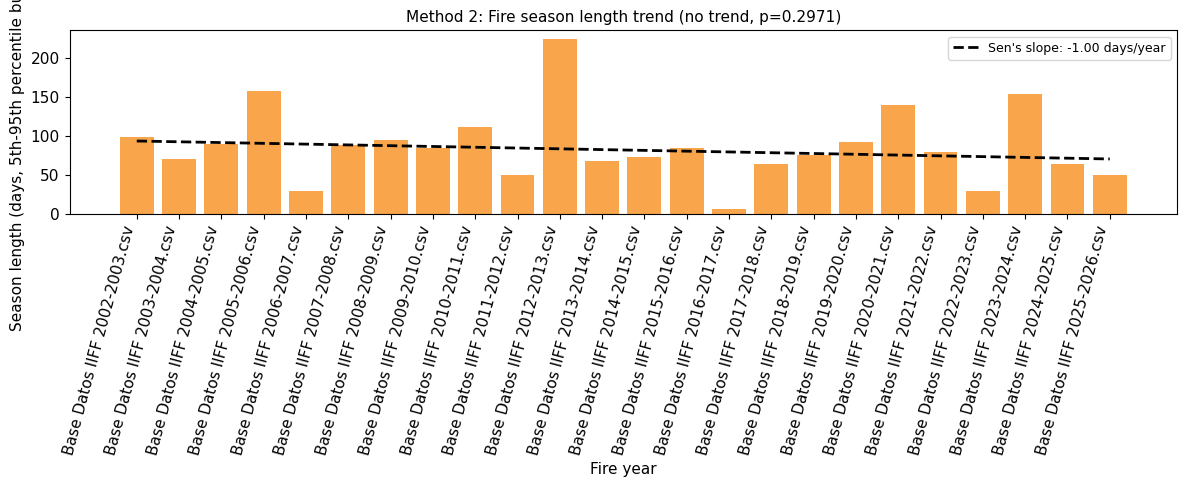

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(trend_data_m2["file"], trend_data_m2["season_length_days"], color=method_colors["method2"], alpha=0.7)
x_numeric = range(len(trend_data_m2))
trend_line_m2 = mk_result_m2.intercept + mk_result_m2.slope * pd.Series(x_numeric)
ax.plot(trend_data_m2["file"], trend_line_m2, color="black", linewidth=2, linestyle="--", label=f"Sen's slope: {mk_result_m2.slope:.2f} days/year")
ax.set_xlabel("Fire year")
ax.set_ylabel("Season length (days, 5th-95th percentile burned area)")
ax.set_title(f"Method 2: Fire season length trend ({mk_result_m2.trend}, p={mk_result_m2.p:.4f})")
ax.legend()
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fig_m2_fsl_length.png", dpi=400, bbox_inches="tight")

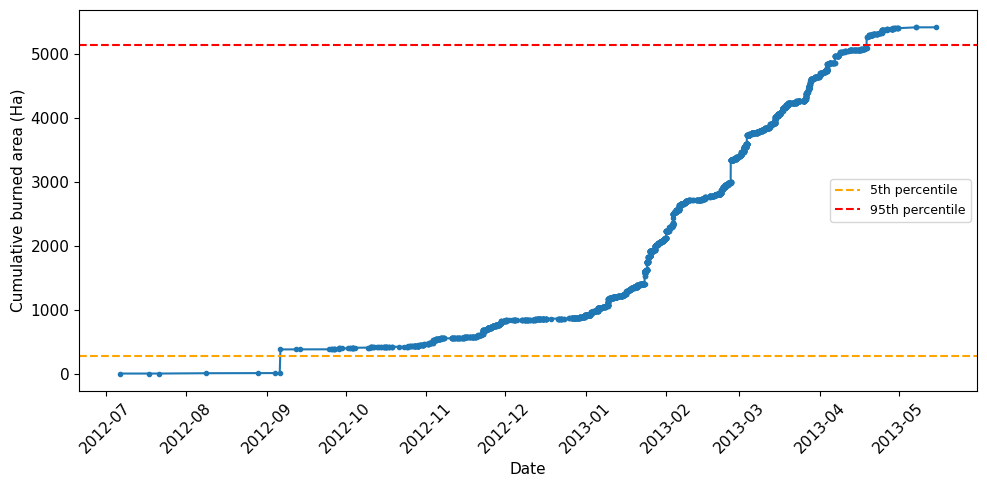

In [43]:
#Looking into the longest year which seems anomalous
outlier_file = [f for f in csv_files if "2012-2013" in f.name][0]

df_check = pd.read_csv(outlier_file, encoding="utf-8").rename(columns=column_renames)
df_check = df_check[df_check["Región"].isin(regions_of_interest)].copy()
df_check["Inicio"] = df_check["Inicio"].apply(parse_spanish_date)
df_check = df_check.dropna(subset=["Inicio", "Superficie total Has"]).sort_values("Inicio")
df_check["cumulative_area"] = df_check["Superficie total Has"].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_check["Inicio"], df_check["cumulative_area"], marker="o", markersize=3)
ax.axhline(0.05 * df_check["cumulative_area"].iloc[-1], color="orange", linestyle="--", label="5th percentile")
ax.axhline(0.95 * df_check["cumulative_area"].iloc[-1], color="red", linestyle="--", label="95th percentile")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative burned area (Ha)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig.savefig("../outputs/m2_1213.png", dpi=400, bbox_inches="tight")

In [44]:
p5_row = df_check[df_check["cumulative_area"] >= 0.05 * df_check["cumulative_area"].iloc[-1]].iloc[0]
p95_row = df_check[df_check["cumulative_area"] >= 0.95 * df_check["cumulative_area"].iloc[-1]].iloc[0]

print("5th percentile fire:", p5_row[["Nombre incendio", "Inicio", "Superficie total Has"]])
print("95th percentile fire:", p95_row[["Nombre incendio", "Inicio", "Superficie total Has"]])

5th percentile fire: Nombre incendio               HUMEDAL TUBUL
Inicio                  2012-09-06 01:00:00
Superficie total Has                  370.0
Name: 3276, dtype: object
95th percentile fire: Nombre incendio          HUMEDAL TUBUL VIII
Inicio                  2013-04-18 17:50:00
Superficie total Has                  182.0
Name: 4185, dtype: object


In [45]:
# Look up the full raw row for the 5th percentile fire (HUMEDAL TUBUL, 6 Sep 2012)
fire_lookup = df_check[
    (df_check["Nombre incendio"].str.contains("TUBUL", case=False, na=False)) &
    (df_check["Inicio"].dt.date == pd.Timestamp("2012-09-06").date())
]

pd.set_option("display.max_columns", None)
print(fire_lookup.T)  # transposed so all columns are visible

                                                           3276
Región                                                   Biobío
Provincia                                                Arauco
Comuna                                                   Arauco
Nombre incendio                                   HUMEDAL TUBUL
Escenario                                                   NaN
Coord. operativas UTM E                                633684 E
Coord. operativas UTM N                               5877192 S
Huso op.                                                    18H
Coord. operativas Lat                               37°14'32" S
Coord. operativas Lon                               73°29'34" O
 Inicio cercano a                                         Otros
 Combustible inicial                                   Pastizal
Causa general                1.2 - Faenas agrícolas y pecuarias
Pino 0 a 10                                                 0.0
Pino 11 a 17                            

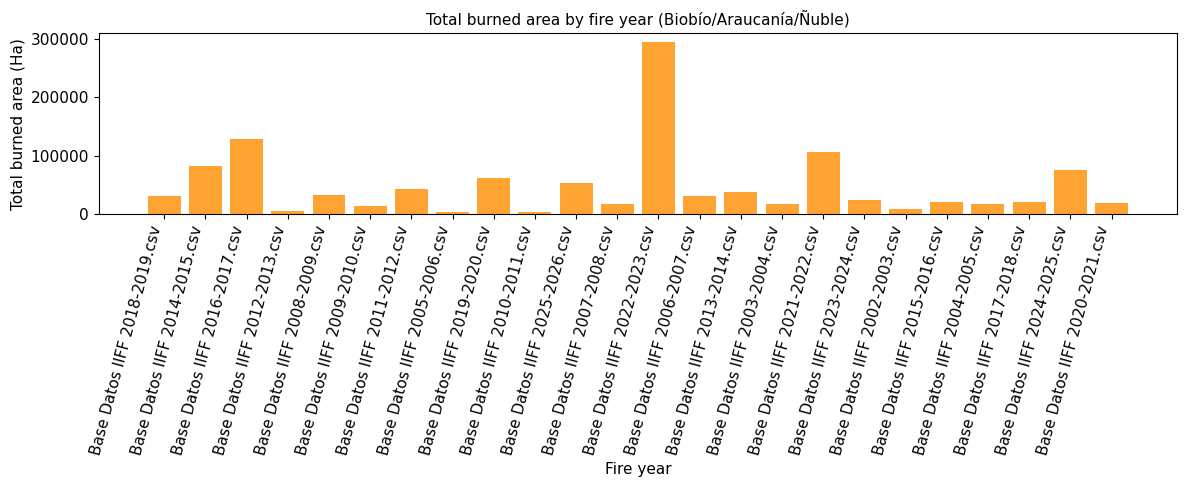

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(method2_df["file"], method2_df["total_area_ha"], color="darkorange", alpha=0.8)
ax.set_xlabel("Fire year")
ax.set_ylabel("Total burned area (Ha)")
ax.set_title("Total burned area by fire year (Biobío/Araucanía/Ñuble)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

fig.savefig("../outputs/burned_area_by_year.png", dpi=400, bbox_inches="tight")

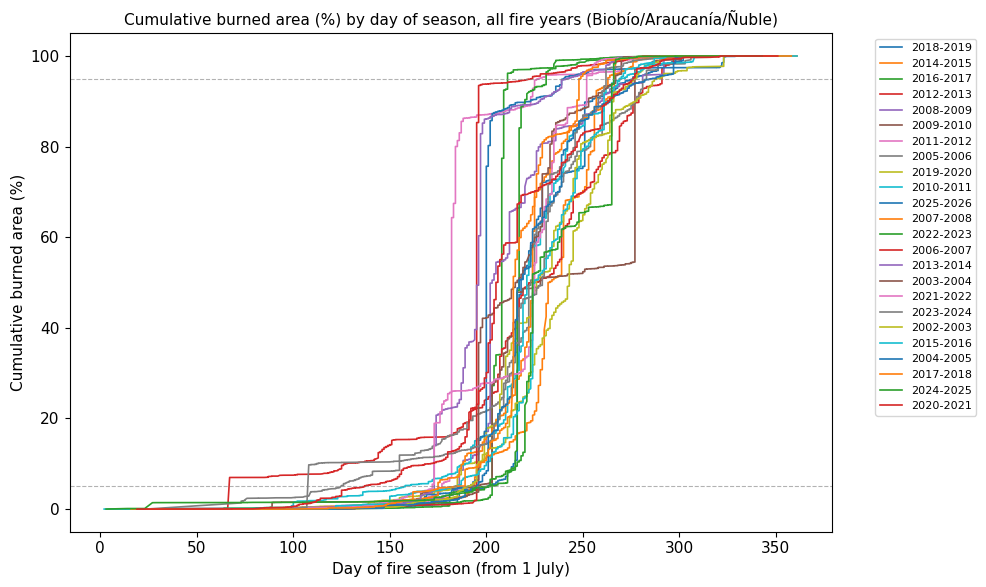

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

for csv_file in csv_files:
    df = pd.read_csv(csv_file, encoding="utf-8").rename(columns=column_renames)
    df_filtered = df[df["Región"].isin(regions_of_interest)].copy()
    df_filtered["Inicio"] = df_filtered["Inicio"].apply(parse_spanish_date)
    
    years_found = re.findall(r'\d{4}', csv_file.name)
    year_start = int(years_found[0])
    fire_year_start = pd.Timestamp(f"{year_start}-07-01")
    fire_year_end = pd.Timestamp(f"{year_start+1}-06-30 23:59:59")
    
    df_filtered = df_filtered[
        (df_filtered["Inicio"] >= fire_year_start) &
        (df_filtered["Inicio"] <= fire_year_end)
    ].dropna(subset=["Inicio", "Superficie total Has"]).sort_values("Inicio")
    
    if len(df_filtered) == 0:
        continue
    
    df_filtered["day_of_season"] = (df_filtered["Inicio"] - fire_year_start).dt.days
    df_filtered["cumulative_area"] = df_filtered["Superficie total Has"].cumsum()
    total_area = df_filtered["cumulative_area"].iloc[-1]
    df_filtered["cumulative_pct"] = (df_filtered["cumulative_area"] / total_area) * 100
    
    label = f"{year_start}-{year_start+1}"
    ax.plot(df_filtered["day_of_season"], df_filtered["cumulative_pct"], label=label, linewidth=1.2)

ax.axhline(5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(95, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlabel("Day of fire season (from 1 July)")
ax.set_ylabel("Cumulative burned area (%)")
ax.set_title("Cumulative burned area (%) by day of season, all fire years (Biobío/Araucanía/Ñuble)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

fig.savefig("../outputs/cum_burned_area.png", dpi=400, bbox_inches="tight")

In [48]:
method1_summary.to_csv("../outputs/method1_results.csv", index=False)
method2_df.to_csv("../outputs/method2_results.csv", index=False)

## Investigating Data

In [49]:
over_365 = method1_summary[method1_summary["season_length_days"] > 365]
over_365

,fire_year,first_ignition_date,last_ignition_date,last_extinction_date,season_length_days,fire_year_start,first_day,last_ignition_day,last_day
15,2017-2018,2017-07-17 14:30:00,2018-06-24 09:45:00,2018-08-07 11:56:00,385,2017-07-01,16,358,402


In [50]:
# Identify the specific fire(s) driving each case
for fy in over_365["fire_year"]:
    fires_in_year = combined_df[combined_df["fire_year"] == fy]
    idx_max = fires_in_year["Extinción"].idxmax()
    row = fires_in_year.loc[idx_max]
    print(f"Fire year {fy}")
    print(f"  Inicio: {row['Inicio']}")
    print(f"  Extinción: {row['Extinción']}")
    print(f"  calculated_duration_hours: {row['calculated_duration_hours']:.1f} ({row['calculated_duration_hours']/24:.1f} days)")
    print()

Fire year 2017-2018
  Inicio: 2018-05-05 11:00:00
  Extinción: 2018-08-07 11:56:00
  calculated_duration_hours: 2256.9 (94.0 days)

